# mc-execute - example 2

### `execute facing` Error verification & visualization

- Comparison of the error with the original angle when executing `facing ^ ^ ^1` multiple times

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from mc_execute import Execute

In [ ]:
def show_facing_error(min_angle=-180.0, max_angle=180.0, steps=2000):
    # Input Data
    yaw_values = np.arange(min_angle, max_angle, (max_angle - min_angle)/steps, dtype=np.float32)
    zeros = np.zeros_like(yaw_values)
    input_rots = np.column_stack((yaw_values, zeros)).astype(np.float32)

    # Method A: execute rotated yaw 0.0
    res_a = Execute().rotated(input_rots).rotations[:, 0]

    # Method B: execute rotated yaw 0.0 facing ^ ^ ^1
    res_b = Execute().rotated(input_rots).facing("^ ^ ^1").rotations[:, 0]

    # Method C: execute rotated yaw 0.0 facing ^ ^ ^1 facing ^ ^ ^1
    res_c = Execute().rotated(input_rots).facing("^ ^ ^1").facing("^ ^ ^1").rotations[:, 0]

    # Method D: execute rotated yaw 0.0 facing ^ ^ ^1 facing ^ ^ ^1 facing ^ ^ ^1
    res_d = Execute().rotated(input_rots).facing("^ ^ ^1").facing("^ ^ ^1").facing("^ ^ ^1").rotations[:, 0]
    
    # Visualization
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

    # [Graph 1] Result Yaw Comparison
    ax1.set_title("Comparison of Rotation Methods")
    ax1.plot(yaw_values, res_a, label='A: rotated yaw 0.', color='black', alpha=0.75, linewidth=1)
    ax1.plot(yaw_values, res_b, label='B: rotated yaw 0. facing ^ ^ ^1', color='red', linewidth=0.5)
    ax1.plot(yaw_values, res_c, label='C: rotated yaw 0. facing ^ ^ ^1 facing ^ ^ ^1', color='dodgerblue', linewidth=0.4)
    ax1.plot(yaw_values, res_d, label='D: rotated yaw 0. facing ^ ^ ^1 facing ^ ^ ^1 facing ^ ^ ^1', color='green', linewidth=0.4)
    ax1.set_xlabel("Input Yaw (Degrees)")
    ax1.set_ylabel("Result Yaw (Degrees)")
    ax1.legend(loc='upper left', markerscale=2.0)
    ax1.grid(True, which='both', linestyle='--', alpha=0.7)

    # Wrap around 180/-180
    def get_angle_diff(arr1, arr2):
        diff = arr1 - arr2
        return (diff + np.float32(180.)) % np.float32(360.) - np.float32(180.)

    diff_b = get_angle_diff(res_b, res_a)
    diff_c = get_angle_diff(res_c, res_a)
    diff_d = get_angle_diff(res_d, res_a)

    # [Graph 2] Precision Error Analysis
    ax2.set_title("Precision Error relative to Method A")
    ax2.plot(yaw_values, diff_b, 'o', label='Error (B - A)', color='red', linewidth=0.25, markersize=0.25, alpha=1.0, linestyle='None')
    ax2.plot(yaw_values, diff_c, 'o', label='Error (C - A)', color='dodgerblue', linewidth=0.25, markersize=0.25, alpha=1.0, linestyle='None')
    ax2.plot(yaw_values, diff_d, 'o', label='Error (D - A)', color='green', linewidth=0.25, markersize=0.25, alpha=1.0, linestyle='None')
    ax2.set_xlabel("Input Yaw (Degrees)")
    ax2.set_ylabel("Error (Degrees)")
    ax2.legend(loc='upper right', markerscale=10)
    ax2.grid(True, which='both', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

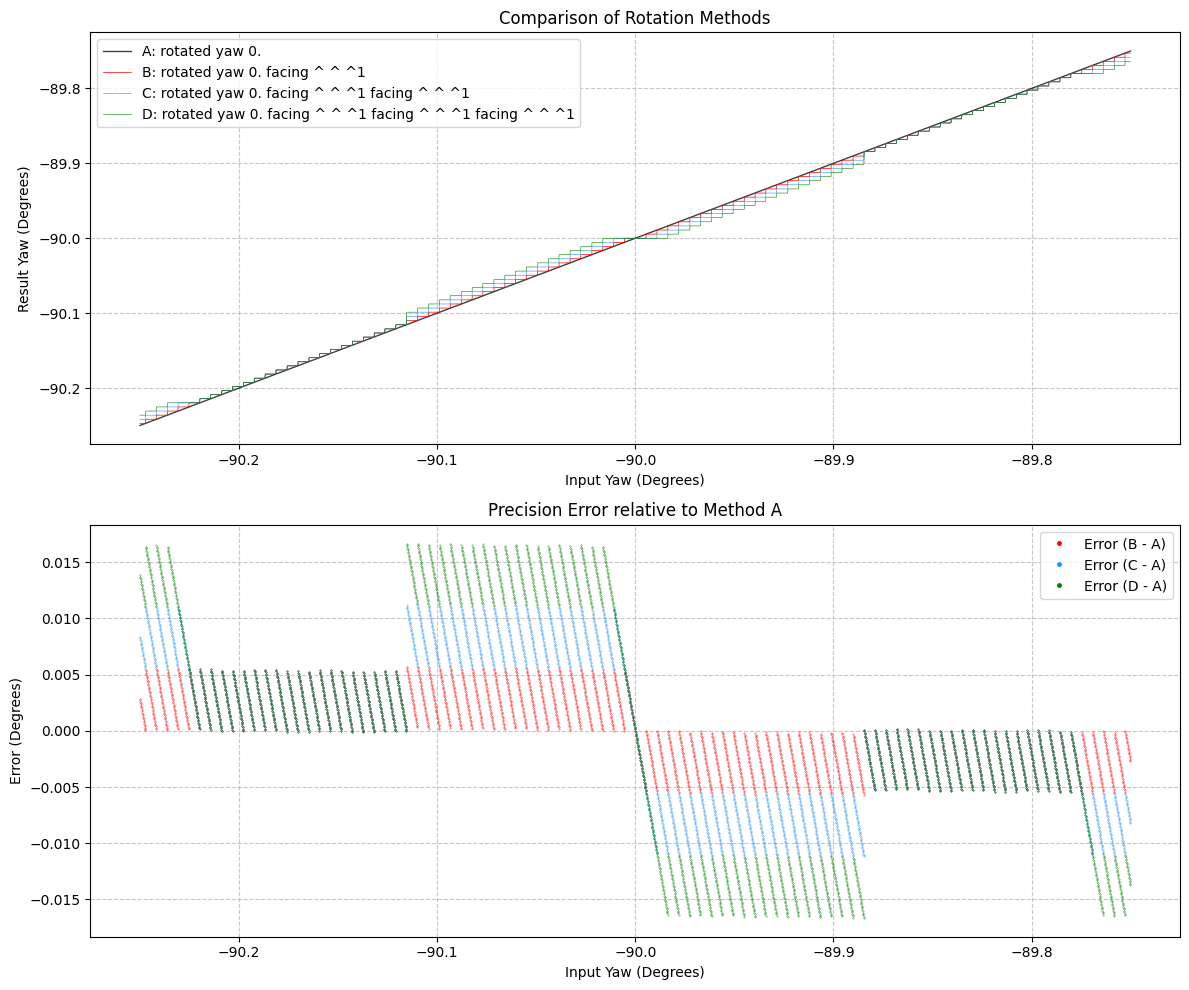

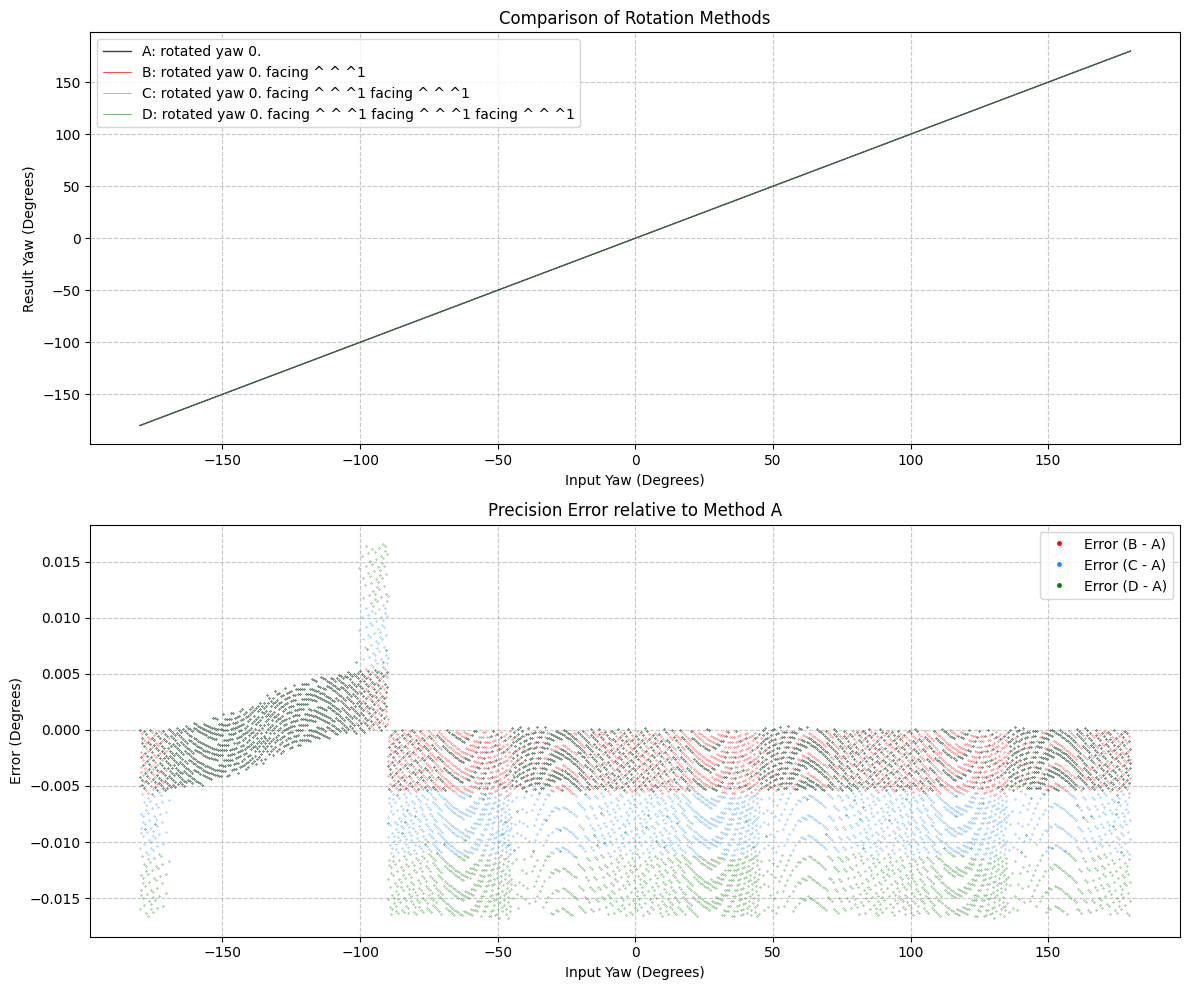

In [20]:
show_facing_error(-90.25, -89.75, 4096)
show_facing_error(-180., 180., 4401)